# K-Nearest Neighbors and Support Vector Machines

## Drug Classification

### Machine Learning Classification Project

**Author:** Juan Manuel Candela | **Date:** March 2026  
**Dataset:** drug200  

**Source:** Kaggle – drug200  
https://www.kaggle.com/datasets/ibrahimbahbah/drug200

---

## 1. Project Overview

This project analyzes patient features to predict which type of drug should be prescribed based on patient characteristics such as age, blood presure, cholesterol levels, and sodium to potassium ratio.. The objective is to build a **K-Nearest Neighbors (KNN)** model and a **Support Vector Machine (SVM)** model and evaluate which one performs better on the dataset in order to accurately predict the appropriate drug.

The dataset was provided by a Kaggle user and includes information related to different patient characteristics such as age, blood pressure, cholesterol level, and blood sodium–potassium ratio.

---

## 2. Dataset Features

- **Age** – Age of the patient  
- **Sex** – Gender of the individual  
- **BP** – Blood pressure level  
- **Cholesterol** – Cholesterol level in blood  
- **Na_to_K** – Sodium-to-potassium ratio in blood  

---

## 3. Project Includes

- Reading and exploring CSV data  
- Data inspection and preprocessing  
- Checking for missing values  
- One-hot encoding for categorical variables  
- Train–test split for model validation  
- Feature scaling using **StandardScaler**  
- Implementation of **K-Nearest Neighbors (KNN)**  
- Implementation of **Support Vector Machine (SVM)**  
- Model evaluation using **accuracy score**  
- Model comparison  
- Prediction test on new patient data

## Libraries

In [1]:
# Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer, make_column_selector

# Model selecton
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

## Exploratory Data Analysis (EDA) & Data Preprocessing & Cleaning

In [2]:
# Read csv
df = pd.read_csv("drug200.csv")

df.head()
df.info()
df.describe()

print()

# Check for null values
print(df.isnull().sum())

# Count data
print("The dataset has: ",df.size," records")

# Find mean of age
print("Mean of age: ",df["Age"].mean())

# Find standard deviation
print("Standard deviation: ",df["Na_to_K"].std())

# Save numeric columns
numeric_columns = df.select_dtypes(include=["int64", "float"])

# Save categorical columns
categorical_columns = df.select_dtypes(include=["object"])

# Correlation matrix
def matrix_corr(df):
    mascara = np.triu(df.corr(numeric_only=True)).T

    fig, ax = plt.subplots()

    sns.heatmap(df.corr(numeric_only=True),
                annot=True,
                lw=0.5,
                mask=mascara)

    ax.set_title("Correlation matrix")
    plt.tight_layout()
    plt.show()


def pairplot(df, condition):

    g = sns.pairplot(data=df, hue=condition, palette="inferno")
    g.fig.suptitle(f"Pairplot by {condition}", y=1)

    plt.show()
  

def histogram(df, condition):
    sns.histplot(df, x=condition, stat="percent")
    plt.show()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64
The dataset has:  1200  records
Mean of age:  44.315
Standard deviation:  7.223955528459516


#### Correlation matrix

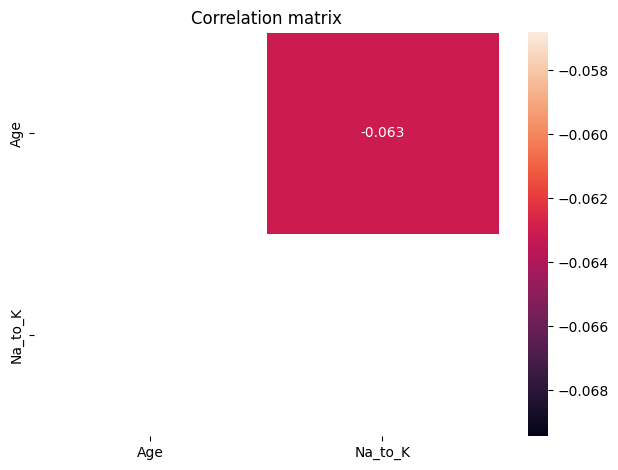

In [3]:
matrix_corr(numeric_columns)

#### Pairplot

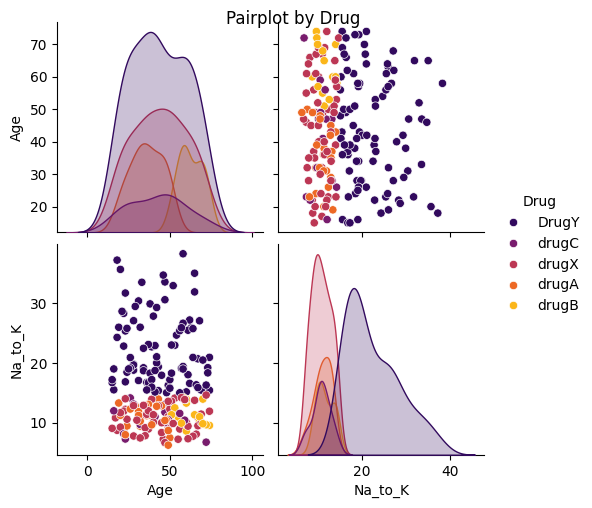

In [4]:
pairplot(df, "Drug")

- In the pairplot, we can see that DrugY is the most commonly used medication in the dataset. It is mainly taken by older people, as well as by individuals with high levels of Na_to_K in their blood.
- The pairplot suggests that the Na_to_K feature strongly separates DrugY from the other classes, indicating that it may be one of the most important predictors

#### Histogram

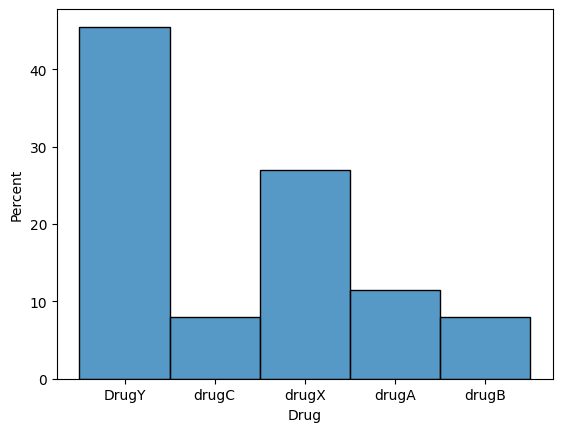

In [5]:
histogram(categorical_columns, "Drug")

- Percentage of used medication in dataset

## Preprocessing

In [6]:
# Target
y = df["Drug"]

# One hot Encoding
def one_hot_encoding(df):
    ct = ColumnTransformer(transformers=[('encoder',OneHotEncoder(), make_column_selector(dtype_include=object))], remainder='passthrough')
    df_trans = ct.fit_transform(df)
    columns = ct.get_feature_names_out() # Recover column names
    df_trans = pd.DataFrame(df_trans, columns=columns)
    return df_trans, ct

df, ct = one_hot_encoding(df.drop(["Drug"], axis=1))

## Train Test Split

In [7]:
# df procesed
X = df

# Data split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  Scalling
sc = StandardScaler()


X_train[["remainder__Age" , "remainder__Na_to_K"]] = sc.fit_transform(X_train[["remainder__Age" , "remainder__Na_to_K"]])
X_test[["remainder__Age" , "remainder__Na_to_K"]] = sc.transform(X_test[["remainder__Age" , "remainder__Na_to_K"]])

## Model Development

### K-Nearest Neighbors

Find the best k value for KNN

In [8]:
# KNN model
neighbors= range(1,51)
def KNN_best_k(X_train, X_test, y_train, y_test):
    training_accuracy = []
    test_accuracy = []
    # Find Best K value in KNN
    for k in neighbors:
        neigh = KNeighborsClassifier(n_neighbors=k)
        neigh.fit(X_train, y_train)
        
        #y_pred_KNN = neigh.predict(X_test)
        
        training_accuracy.append(neigh.score(X_train, y_train))
        test_accuracy.append(neigh.score(X_test, y_test))
        
    #return training_accuracy, test_accuracy
    
    plt.title("KNN accuracy for diffetent K values")
    plt.plot(neighbors, training_accuracy, label="Training accuracy")
    plt.plot(neighbors, test_accuracy, label="Test accuracy")
    plt.xticks(np.arange(1,50,4))
    plt.vlines(9, 0.8, 1, label="Best K", colors="black", linestyles="--")
    plt.ylabel("Accuracy")
    plt.xlabel("K values")
    plt.legend()
    plt.show()

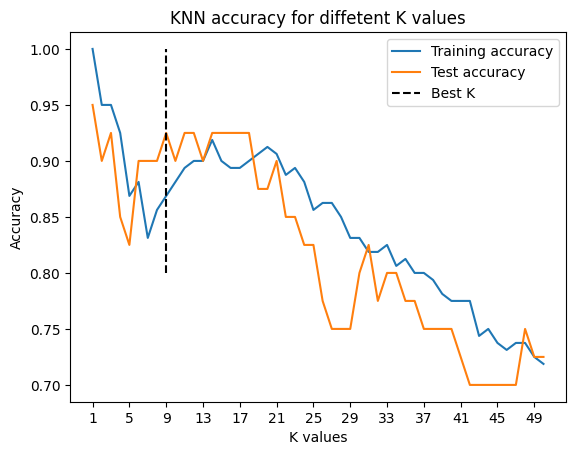

In [9]:
KNN_best_k(X_train, X_test, y_train, y_test)

- In this plot, we can observe the optimal k for the KNN model. We select the first stable k value shown in the plot, which is 9.

### KNN with the best k value

In [ ]:
# KNN with best k = 9
def KNN(X_train, X_test, y_train, y_test):
    # KNN with k=9
    neigh = KNeighborsClassifier(n_neighbors=9)
    neigh.fit(X_train, y_train)
    
    # Predict
    y_pred_knn = neigh.predict(X_test)
    
    # Accuracy
    accuracy = neigh.score(X_test, y_test)
    
    # Confusion matrix
    confusion = confusion_matrix(y_test, y_pred_knn)

    return y_pred_knn, accuracy, confusion, neigh

y_pred_KNN, accuracy_knn, confusionMatrixKnn, neigh = KNN(X_train, X_test, y_train, y_test)

## Support Vector Machines

In [11]:
def SVM_model(X_train, X_test, y_train, y_test):
    
    clf = SVC(kernel="sigmoid")
    # Fit model
    clf.fit(X_train, y_train)
    
    # Predict
    y_pred_svc = clf.predict(X_test)
    
    # Mean accuracy
    score_svc = clf.score(X_test, y_test)

    # Confusion matrix
    confusion = confusion_matrix(y_test, y_pred_svc)
 
    return y_pred_svc, score_svc, confusion, clf
    
    
    
y_pred_svm, accuracy_svm, confusionMatrixSvm, clf = SVM_model(X_train, X_test, y_train, y_test)

### KNN Vs. SVM

Accurary

In [12]:
print(f"The accuracy for KNN: {accuracy_knn}")
print(f"The accurary for SVM: {accuracy_svm}")

The accuracy for KNN: 0.925
The accurary for SVM: 0.9


- After running both models, they achieved 92.5% accuracy for KNN and 90% for SVM. The difference between them is minimal, so we analyze what happens in the confusion matrix.

Confusion Matrix

Text(0.5, 1.0, 'Confusion matix KNN')

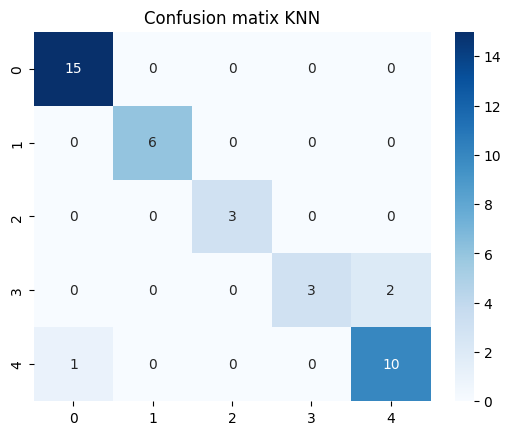

In [23]:
y = sns.heatmap(confusionMatrixKnn, annot=True, fmt="d", cmap="Blues")
y.set_title("Confusion matix KNN")

Text(0.5, 1.0, 'Confusion matix SVM')

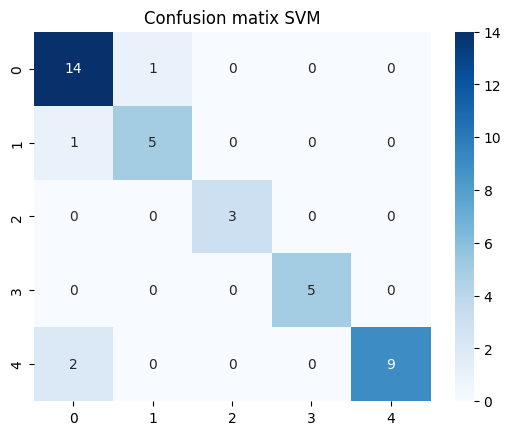

In [24]:
y = sns.heatmap(confusionMatrixSvm, annot=True, fmt="d", cmap="Blues")
y.set_title("Confusion matix SVM")

- We can see that KNN fits the dataset better, with 1 false positive, while SVM has 2 false positives.

### Classification report

KNN

In [15]:
print(classification_report(y_test, y_pred_KNN))

              precision    recall  f1-score   support

       DrugY       0.94      1.00      0.97        15
       drugA       1.00      1.00      1.00         6
       drugB       1.00      1.00      1.00         3
       drugC       1.00      0.60      0.75         5
       drugX       0.83      0.91      0.87        11

    accuracy                           0.93        40
   macro avg       0.95      0.90      0.92        40
weighted avg       0.93      0.93      0.92        40



SVM

In [16]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

       DrugY       0.82      0.93      0.88        15
       drugA       0.83      0.83      0.83         6
       drugB       1.00      1.00      1.00         3
       drugC       1.00      1.00      1.00         5
       drugX       1.00      0.82      0.90        11

    accuracy                           0.90        40
   macro avg       0.93      0.92      0.92        40
weighted avg       0.91      0.90      0.90        40



- The classification report shows a better fit for DrugY, which is the most commonly used medication in this dataset. Therefore, the best option for this dataset is KNN.

## Patient prediction

In [17]:
pacient = pd.DataFrame({"Age": [23],
                        "Sex": ["F"],
                        "BP": ["HIGH"],
                        "Cholesterol": ["HIGH"],
                        "Na_to_K": [25.355]})

# Person transform
person_trans = ct.transform(pacient)
person_trans = pd.DataFrame(person_trans, columns=ct.get_feature_names_out())

person_trans[["remainder__Age" , "remainder__Na_to_K"]] = sc.transform(person_trans[["remainder__Age" , "remainder__Na_to_K"]])

person_pred_knn = neigh.predict(person_trans)

person_pred_clf = clf.predict(person_trans)

In [18]:
print(f"Support Vector Classification predict: {person_pred_clf}")

Support Vector Classification predict: ['DrugY']


In [19]:
print(f"K-Nearest Neighbors predict: {person_pred_knn}")

K-Nearest Neighbors predict: ['DrugY']


## Conclusion

- Even though both models predicted the same drug, the evaluation metrics show that KNN achieved slightly higher accuracy and fewer false positives than SVM. This suggests that KNN fits this dataset better, making it a more suitable model for predicting medication in this case, especially when working with larger volumes of patient data.

limitatios
1. Small datset.
2. This model performace may not generalize.
3. Medical decision require clinical validation.